In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
import warnings

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
os.makedirs('output', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Load data
df_train     = pd.read_csv('../processed/train_processed.csv')
df_test_last = pd.read_csv('../processed/test_last_cycle.csv')

with open('../processed/feature_cols.json') as f:
    feature_cols = json.load(f)

print(f'Train shape     : {df_train.shape}')
print(f'Test last shape : {df_test_last.shape}')
print(f'Jumlah fitur    : {len(feature_cols)}')

Train shape     : (20631, 27)
Test last shape : (100, 27)
Jumlah fitur    : 16


### Persiapan Feature Matrix (X, y)

In [12]:
def add_rolling_features(df, feature_cols, window=10):
    roll_feats = []
    for col in feature_cols:
        roll_mean = df.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        roll_std  = df.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0)
        )
        df[f'{col}_rmean'] = roll_mean
        df[f'{col}_rstd']  = roll_std
        roll_feats += [f'{col}_rmean', f'{col}_rstd']
    return df, roll_feats

df_train, roll_feats = add_rolling_features(df_train, feature_cols, window=10)

all_feats = feature_cols + roll_feats
print(f'Total fitur (termasuk rolling): {len(all_feats)}')

X_train = df_train[all_feats].values
y_train = df_train['RUL'].values

df_test_full = pd.read_csv('../processed/test_processed.csv')
df_test_full, _ = add_rolling_features(df_test_full, feature_cols, window=10)
df_test_full_last = df_test_full.groupby('unit_number').last().reset_index()

df_test_last_rul = pd.read_csv('../processed/test_last_cycle.csv')
X_test = df_test_full_last[all_feats].values
y_test = df_test_last_rul['RUL'].values

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape},  y_test : {y_test.shape}')

Total fitur (termasuk rolling): 48
X_train: (20631, 48), y_train: (20631,)
X_test : (100, 48),  y_test : (100,)


### Training XGBoost

In [13]:
xgb_params = {
    'n_estimators'     : 500,
    'max_depth'        : 6,
    'learning_rate'    : 0.05,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 3,
    'reg_alpha'        : 0.1,   # L1 regularization
    'reg_lambda'       : 1.0,   # L2 regularization
    'random_state'     : 42,
    'n_jobs'           : -1,
    'early_stopping_rounds': 30
}

# Split sebagian train untuk validation (early stopping)
val_split = int(0.9 * len(X_train))
X_tr, X_val = X_train[:val_split], X_train[val_split:]
y_tr, y_val = y_train[:val_split], y_train[val_split:]

xgb_model = XGBRegressor(**xgb_params)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f'\nBest iteration: {xgb_model.best_iteration}')

[0]	validation_0-rmse:39.77426
[50]	validation_0-rmse:18.80331
[99]	validation_0-rmse:18.58453

Best iteration: 69


### Evaluasi XGBoost

In [14]:
def evaluate_model(y_true, y_pred, model_name='Model'):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    
    # Score function — NASA scoring function untuk RUL
    def nasa_score(y_true, y_pred):
        diff = y_pred - y_true
        score = np.sum(np.where(diff < 0, np.exp(-diff/13) - 1, np.exp(diff/10) - 1))
        return score
    
    ns = nasa_score(y_true, y_pred)
    
    print(f'\n=== Evaluasi {model_name} ===')
    print(f'  RMSE       : {rmse:.4f}')
    print(f'  MAE        : {mae:.4f}')
    print(f'  R²         : {r2:.4f}')
    print(f'  NASA Score : {ns:.2f}')
    
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NASA_Score': ns}

y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb = np.clip(y_pred_xgb, 0, 125)  # Clip agar tidak negatif

metrics_xgb = evaluate_model(y_test, y_pred_xgb, model_name='XGBoost')


=== Evaluasi XGBoost ===
  RMSE       : 19.0761
  MAE        : 13.2783
  R²         : 0.7734
  NASA Score : 1650.84


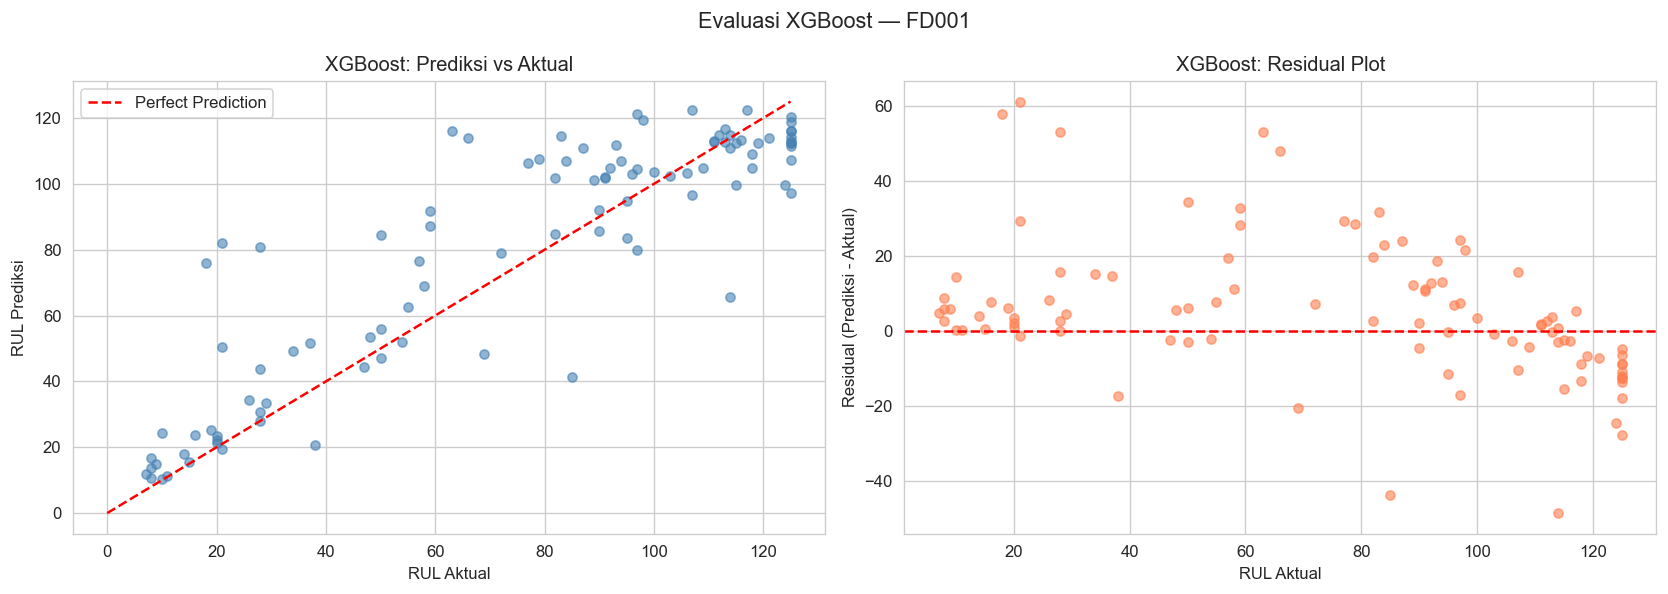

In [15]:
# Plot: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_xgb, alpha=0.6, color='steelblue', s=30)
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('RUL Aktual')
axes[0].set_ylabel('RUL Prediksi')
axes[0].set_title('XGBoost: Prediksi vs Aktual')
axes[0].legend()

# Residual plot
residuals = y_pred_xgb - y_test
axes[1].scatter(y_test, residuals, alpha=0.6, color='coral', s=30)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('RUL Aktual')
axes[1].set_ylabel('Residual (Prediksi - Aktual)')
axes[1].set_title('XGBoost: Residual Plot')

plt.suptitle('Evaluasi XGBoost — FD001', fontsize=13)
plt.tight_layout()
plt.savefig('../output/xgb_evaluation.png')
plt.show()

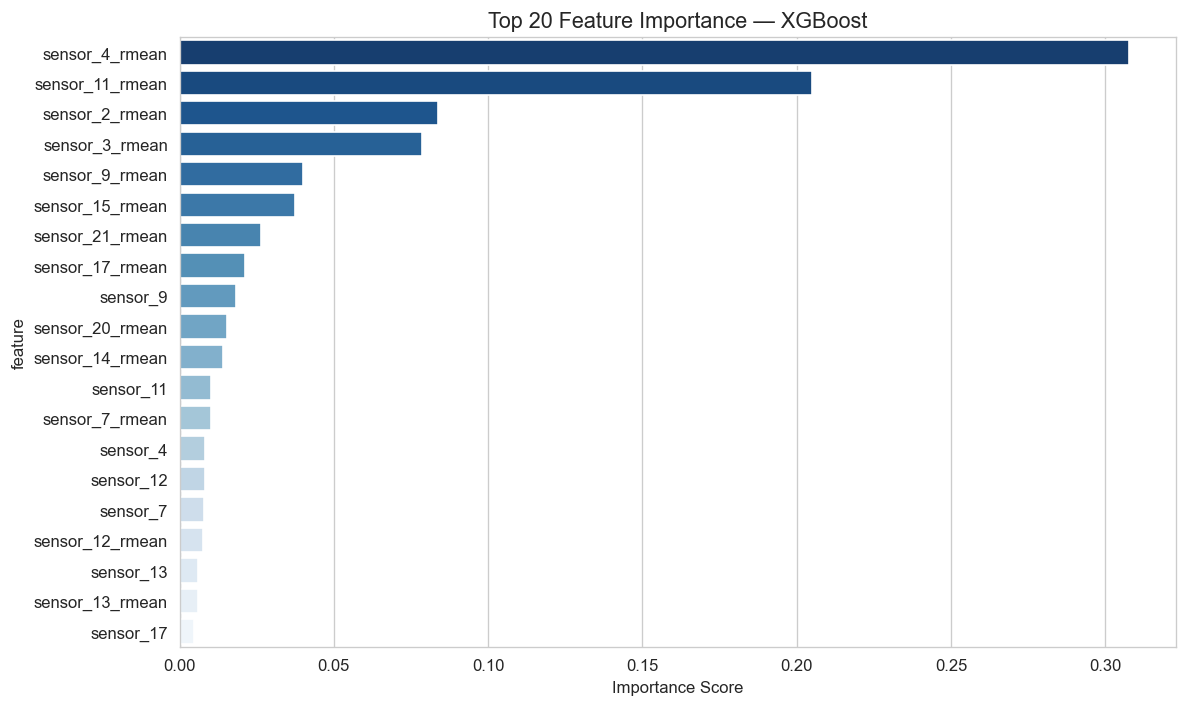

In [16]:
# Feature Importance
importance_df = pd.DataFrame({
    'feature': all_feats,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='Blues_r')
plt.title('Top 20 Feature Importance — XGBoost', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../output/xgb_feature_importance.png')
plt.show()

In [17]:
xgb_cv = XGBRegressor(
    n_estimators=xgb_model.best_iteration,
    max_depth=6, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=3,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = np.sqrt(-cross_val_score(xgb_cv, X_train, y_train,
                                   cv=kf, scoring='neg_mean_squared_error', n_jobs=-1))

print('=== Cross-Validation XGBoost (5-Fold) ===')
for i, rmse in enumerate(cv_rmse, 1):
    print(f'  Fold {i}: RMSE = {rmse:.4f}')
print(f'  Mean RMSE : {cv_rmse.mean():.4f}')
print(f'  Std RMSE  : {cv_rmse.std():.4f}')

=== Cross-Validation XGBoost (5-Fold) ===
  Fold 1: RMSE = 16.3582
  Fold 2: RMSE = 16.0998
  Fold 3: RMSE = 16.1421
  Fold 4: RMSE = 15.7177
  Fold 5: RMSE = 16.2027
  Mean RMSE : 16.1041
  Std RMSE  : 0.2122


### Simpan Model & Hasil

In [19]:
# Simpan model
joblib.dump(xgb_model, 'models/xgb_model.pkl')

# Simpan predictions
pred_df = pd.DataFrame({'y_true': y_test, 'y_pred_xgb': y_pred_xgb})
pred_df.to_csv('../processed/xgb_predictions.csv', index=False)

# Simpan metrics
import json
with open('../processed/xgb_metrics.json', 'w') as f:
    json.dump(metrics_xgb, f, indent=2)